<a href="https://colab.research.google.com/github/hashemwa/CSE-482-Project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.probability import FreqDist
from collections import Counter
from nltk.util import bigrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
df = pd.read_csv('twitter_training.csv', names=['tweet_id', 'subject', 'sentiment', 'review_text'])

In [23]:
## Cleaning

ENGLISH_STOPWORDS_SET = set(stopwords.words('english'))

def remove_stopwords_from_list(token_list):
    """
    Filters a list of tokens, returning only those not in the stopword set.
    """
    # This list comprehension is the efficient way to filter tokens
    return [word for word in token_list if word not in ENGLISH_STOPWORDS_SET]

def remove_punctuation_from_list(token_list):
    """
    Filters a list of tokens, returning only those not in the stopword set.
    """
    # This list comprehension is the efficient way to filter tokens
    return [word for word in token_list if word not in punctuation]

df = df[df["sentiment"].isin(["Positive", "Negative"])]

df["review_text"] = df["review_text"].astype("string")

df["cleaned_text"] = df["review_text"].str.lower()

df = df.dropna(subset= ["cleaned_text"])

# Remove whitespace
df["cleaned_text"] = df["cleaned_text"].str.replace(r'\s+', ' ', regex=True)

df = df.drop_duplicates(subset = ["cleaned_text"])

df["tokens"] = df["cleaned_text"].apply(word_tokenize)

# remove punctuation
df["tokens"] = df["tokens"].apply(remove_punctuation_from_list)

df["tokens"] = df["tokens"].apply(remove_stopwords_from_list)

# Tokenization complete



LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


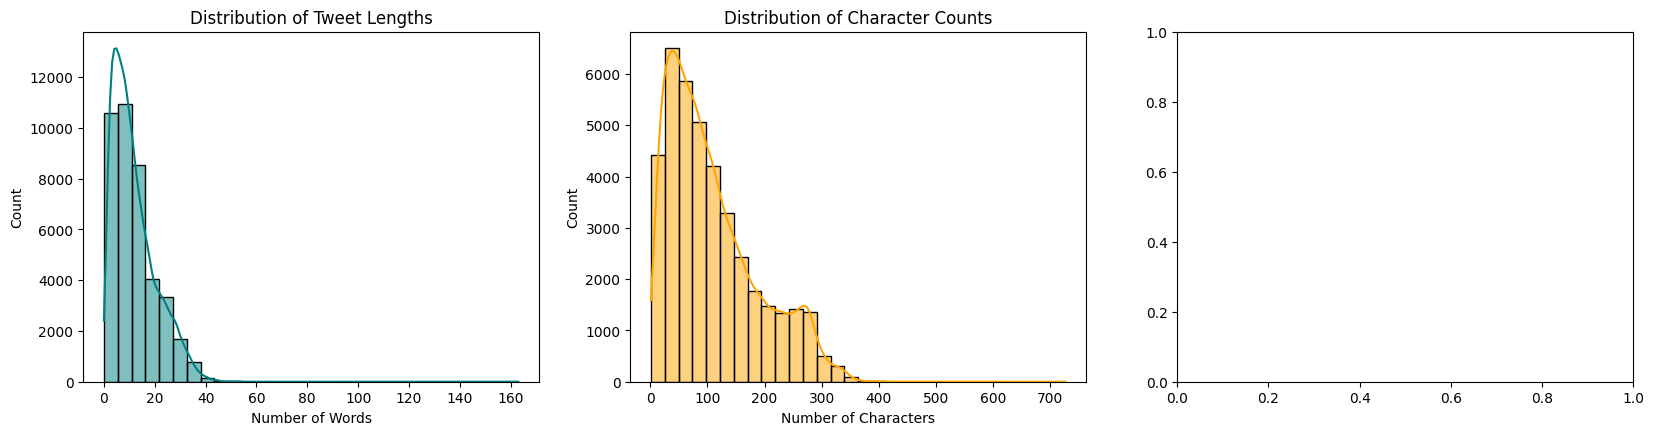

In [24]:
def explore_data_structure(df):

    plt.figure(figsize=(20, 10))

    # 1. Tweet Length (Word Count)
    plt.subplot(2, 3, 1)
    df['doc_len'] = df['tokens'].apply(len)
    sns.histplot(df['doc_len'], bins=30, kde=True, color='teal')
    plt.title('Distribution of Tweet Lengths')
    plt.xlabel('Number of Words')

    # 2. Character Length (Raw Text)
    plt.subplot(2, 3, 2)
    char_len = df['cleaned_text'].str.len()
    sns.histplot(char_len, bins=30, kde=True, color='orange')
    plt.title('Distribution of Character Counts')
    plt.xlabel('Number of Characters')

    # 3. Parts of Speech (POS)
    plt.subplot(2, 3, 3)
    all_tokens = [word for tokens in df['tokens'] for word in tokens]
    pos_tags = nltk.pos_tag(all_tokens)
    pos_freq = FreqDist(tag for (word, tag) in pos_tags)
    pos_df = pd.DataFrame(pos_freq.most_common(10), columns=['POS', 'Frequency'])
    sns.barplot(data=pos_df, x="POS", y="Frequency", palette='coolwarm')
    plt.title('Top 10 Parts of Speech')
    plt.xlabel('POS Tag')

    # 4. Print Summary Stats
    plt.tight_layout()
    plt.show()

    print(f"Average Words per Tweet: {df['doc_len'].mean():.2f}")

explore_data_structure(df)

In [ ]:
## N-gram generator

def get_ngrams(text, n):
  ## I was having issues with NLTK bigrams function. Apparenty it creates generator objects so it doesnt actually calulate the bigrams right away bc of
  ## potential large input. If you guys run into this type of issue, exhause the generator by creating a list().

  return list(nltk.ngrams(text, n))

df["bigrams"] = df["tokens"].apply(lambda tokens: get_ngrams(tokens, 2))

df["trigrams"] = df["tokens"].apply(lambda tokens: get_ngrams(tokens, 3))



In [25]:
## EDA
pos_review_t = []
neg_review_t = []

tokens_location = df.columns.get_loc("tokens")
sentiment_location = df.columns.get_loc("sentiment")

for i in range(0, len(df)):
  if df.iloc[i, sentiment_location] == "Negative":
    for word in df.iloc[i, tokens_location]:
      neg_review_t.append(word)

  else:
    for word in df.iloc[i, tokens_location]:
      pos_review_t.append(word)


word_pos_fdist = FreqDist(pos_review_t)

word_neg_fdist = FreqDist(neg_review_t)

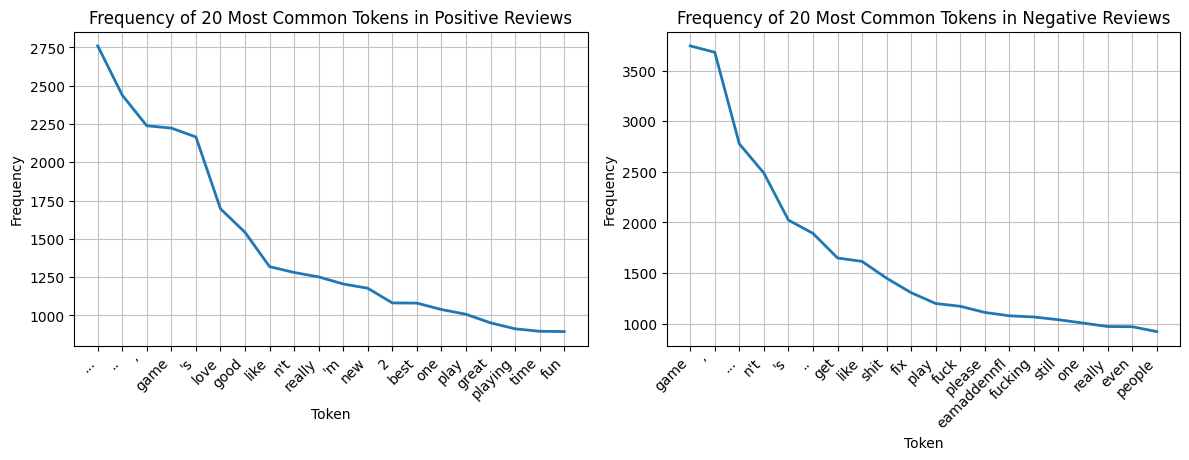

In [26]:
plt.figure(figsize = (12, 8))

plt.subplot(2, 2, 1)

word_pos_fdist.plot(20, cumulative = False)
ax1 = plt.gca()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Positive Reviews")

plt.subplot(2, 2, 2)

word_neg_fdist.plot(20, cumulative = False)
ax2 = plt.gca()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Negative Reviews")


plt.tight_layout()
plt.show()

In [27]:
pos_review_bigrams = []
neg_review_bigrams = []

bigrams_location = df.columns.get_loc("bigrams")
sentiment_location = df.columns.get_loc("sentiment")

for i in range(0, len(df)):
  if df.iloc[i, sentiment_location] == "Negative":
    for bigram in df.iloc[i, bigrams_location]:
      pos_review_bigrams.append(bigram)

  else:
    for bigram in df.iloc[i, bigrams_location]:
      neg_review_bigrams.append(bigram)


bigram_pos_fdist = FreqDist(pos_review_bigrams)

bigram_neg_fdist = FreqDist(neg_review_bigrams)

KeyError: 'bigrams'

NameError: name 'bigram_pos_fdist' is not defined

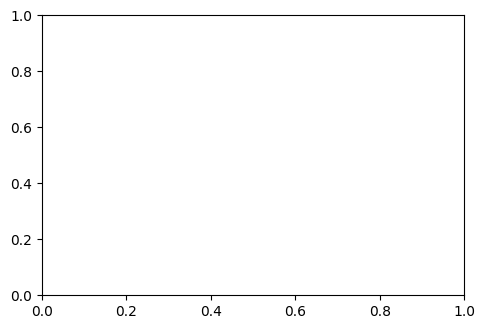

In [28]:
plt.figure(figsize = (12, 8))

plt.subplot(2, 2, 1)

bigram_pos_fdist.plot(20, cumulative = False)
ax1 = plt.gca()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Positive Reviews")

plt.subplot(2, 2, 2)

bigram_neg_fdist.plot(20, cumulative = False)
ax2 = plt.gca()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation = 45, ha = "right")
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Frequency of 20 Most Common Tokens in Negative Reviews")


plt.tight_layout()
plt.show()

In [29]:
## Finding which frequently occuring Bigrams exist in both positive and negative sentiment reviews

from typing import Unpack
pos_neg_duplicate_bigrams = []

top_20_pos_bigrams = bigram_pos_fdist.most_common(20)
top_20_neg_bigrams = bigram_neg_fdist.most_common(20)

bigrams_temp, freq = zip(*top_20_pos_bigrams)
bigrams_temp_list = list(bigrams_temp)

for bigram, count in bigram_neg_fdist.most_common(20):
  if bigram in bigrams_temp_list:
    pos_neg_duplicate_bigrams.append(bigram)


NameError: name 'bigram_pos_fdist' is not defined

In [30]:
data_to_add = []

for bigram, freq in top_20_pos_bigrams:
  if bigram in pos_neg_duplicate_bigrams:
    new_row = {
        "bigram" : bigram,
        "sentiment" : "Positive",
        "count" : freq
    }

    data_to_add.append(new_row)

for bigram, freq in top_20_neg_bigrams:
  if bigram in pos_neg_duplicate_bigrams:
    new_row = {
        "bigram" : bigram,
        "sentiment" : "Negative",
        "count" : freq
    }

    data_to_add.append(new_row)

df_duplicate_bigrams = pd.DataFrame(data_to_add)

totals = df_duplicate_bigrams.groupby("bigram").agg(
    total = ("count", "sum")
).reset_index()

combined = pd.merge(df_duplicate_bigrams, totals, how = "left", on = "bigram")

combined["proportion"] = round(combined["count"] / combined["total"], 2)

combined = combined.sort_values(by = ["sentiment", "count"], ascending = [False, True])

combined


NameError: name 'top_20_pos_bigrams' is not defined

In [ ]:
### Bar plot to show proportion of frequency of duplicate bigrams in the top 20 most frequent positive and negative Reviews

#pivot data for stacking
df_pivot = combined.pivot_table(
    index = "bigram",
    columns = "sentiment",
    values = "count"
)

#get index correct order based on total
total_sort_order = combined[["bigram", "total"]].drop_duplicates().sort_values(by = "total", ascending = False)["bigram"]

#reindex pivoted table
df_stack = df_pivot.reindex(total_sort_order)

#create stacked bar plot
ax = df_stack.plot(
    kind = "bar",
    stacked = True,
    figsize= (10, 8),
    color = {"Positive": "#009933", "Negative": "#cc0000"}
)

ax.set_title("Stacked Frequency Chart of Bigrams most Frequent in Positive and Negative Reviews")
ax.set_xlabel("Bigram")
ax.set_ylabel("Total Count")

for container in ax.containers:
    labels = [f"{count / df_stack.sum(axis = 1)[i]:.1%}" if count > 0 else ""
    for i, count in enumerate(container.datavalues)]
    ax.bar_label(container, labels = labels, label_type = "center", color = "white", weight = "bold")

plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()

In [31]:
# TF - IDF
df_copy = df
# df_copy.head()

# Split the dataframe by sentiment
df_positive = df_copy[df_copy['sentiment'] == 'Positive'].copy()
df_negative = df_copy[df_copy['sentiment'] == 'Negative'].copy()

print(f"Positive reviews: {len(df_positive)}")
print(f"Negative reviews: {len(df_negative)}")


Positive reviews: 18982
Negative reviews: 21096


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer


# Function to get top N words using TF-IDF
def get_top_words_tfidf(texts, top_n=10):
    """
    Apply TF-IDF and return top N words
    """
    vectorizer = TfidfVectorizer(
        max_features=200,
        min_df=5,
        max_df=0.95,
        ngram_range=(1, 1),  # Only single words
        stop_words='english'
    )

    # Fit and transform
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()

    # Calculate mean TF-IDF score for each word
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

    # Get top N words
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]

    top_words = pd.DataFrame({
        'word': [feature_names[i] for i in top_indices],
        'tfidf_score': [mean_tfidf[i] for i in top_indices]
    })

    return top_words

# Get top 10 words for positive reviews
print("TOP 10 WORDS - POSITIVE REVIEWS")

top_positive = get_top_words_tfidf(df_positive['cleaned_text'], top_n=10)
print(top_positive)

# Get top 10 words for negative reviews
print("\nTOP 10 WORDS - NEGATIVE REVIEWS")

top_negative = get_top_words_tfidf(df_negative['cleaned_text'], top_n=10)
print(top_negative)

TOP 10 WORDS - POSITIVE REVIEWS
     word  tfidf_score
0    love     0.037408
1    game     0.035968
2    good     0.032816
3     com     0.029577
4    just     0.029036
5    like     0.025026
6    best     0.024757
7  really     0.024143
8     new     0.023847
9     pic     0.022413

TOP 10 WORDS - NEGATIVE REVIEWS
          word  tfidf_score
0         game     0.047784
1         just     0.032990
2         shit     0.028686
3          com     0.026970
4         fuck     0.025211
5         like     0.024432
6  eamaddennfl     0.023523
7          fix     0.022084
8          pic     0.021400
9      verizon     0.021223


Accuracy: 0.7614770459081837
              precision    recall  f1-score   support

           0       0.74      0.84      0.79      4227
           1       0.79      0.68      0.73      3789

    accuracy                           0.76      8016
   macro avg       0.77      0.76      0.76      8016
weighted avg       0.76      0.76      0.76      8016

Confusion Matrix: [[3531  696]
 [1216 2573]]


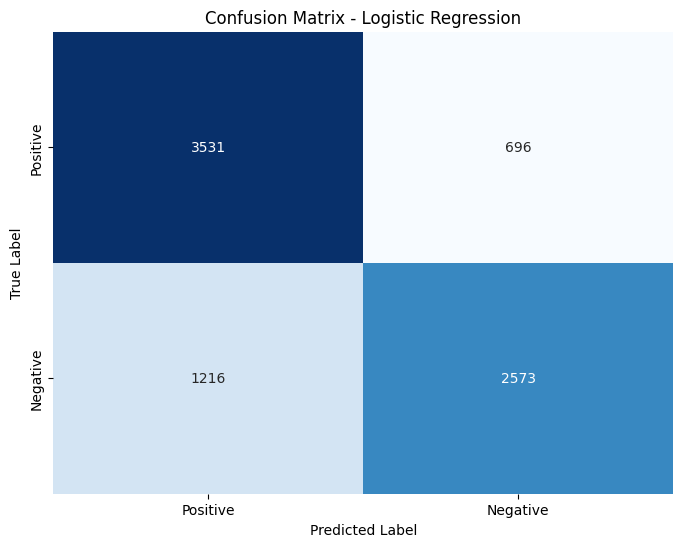

In [33]:
# Logistic Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Vectorize using TF-IDF
vectorizer = TfidfVectorizer(max_features=200, min_df=5, max_df=0.95, stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['cleaned_text'])
y = (df['sentiment'] == 'Positive').astype(int)


# Split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [ ]:
import statsmodels.api as sm
logit_model = sm.Logit(y_train.values.ravel(), sm.add_constant(X_train.toarray()))
result = logit_model.fit()
print(result.summary())

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

In [41]:


# Initialize the vectorizer with custom settings
vectorizer_NB = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2)  # Use both single words and pairs of words
)

X_nb = vectorizer_NB.fit_transform(df['cleaned_text'])
y_nb = (df['sentiment'] == 'Positive').astype(int)

# Split the data into training and testing sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb,
    test_size=0.2,
    random_state=42,
    stratify=y_nb # Ensures the proportion of 'Positive' is maintained in both sets
)

print(f"Training set size: {X_train_nb.shape[0]} reviews")
print(f"Testing set size: {X_test_nb.shape[0]} reviews")



Training set size: 32062 reviews
Testing set size: 8016 reviews


In [46]:
X_nb.shape

(40078, 160066)

In [42]:
# Initialize the Multinomial Naive Bayes model
# alpha=1.0 is the default (Laplace smoothing) to handle zero probabilities
mnb = MultinomialNB(alpha=1.0)

# Train the model using the training data
mnb.fit(X_train_nb, y_train_nb)

print("Model Training Complete.")

Model Training Complete.


In [43]:
# Make predictions on the test set
y_pred_nb = mnb.predict(X_test_nb)

# Calculate Accuracy
accuracy = accuracy_score(y_test_nb, y_pred_nb)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print detailed Classification Report
print("\n--- Classification Report ---")
# Target names are defined for clarity: 1 is 'Positive', 0 is 'Other/Negative'
print(classification_report(y_test_nb, y_pred_nb, target_names=['Other/Negative (0)', 'Positive (1)']))


Accuracy Score: 0.9501

--- Classification Report ---
                    precision    recall  f1-score   support

Other/Negative (0)       0.96      0.95      0.95      4219
      Positive (1)       0.94      0.95      0.95      3797

          accuracy                           0.95      8016
         macro avg       0.95      0.95      0.95      8016
      weighted avg       0.95      0.95      0.95      8016

